# Qiskit Fall Fest 2026 — Challenge 1: Predict the Output
**IBM Quantum | Vishnu Institute of Technology**

## Objective
Create three single-qubit circuits, predict their measurement outcomes, execute each circuit for 100 shots, record the counts, display histograms, and compare predictions with the results.

## 1. Setup
If Qiskit is not installed in your environment, run the following cell. If you are using Google Colab, you can run it there as well.

In [1]:
%pip install -q qiskit qiskit-aer matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

SHOTS = 100
simulator = AerSimulator()
print('Setup complete. Each circuit will run for', SHOTS, 'shots.')

Setup complete. Each circuit will run for 100 shots.


## 2. Predict before running

| Circuit | Gates | Prediction before execution | Reason |
|---|---|---|---|
| A | One X gate | 100 outcomes of `1` | X flips `|0⟩` to `|1⟩`. |
| B | Two X gates | 100 outcomes of `0` | The second X reverses the first. |
| C | One H gate | Approximately 50 `0`s and 50 `1`s | H creates an equal superposition; measurement is probabilistic. |

**Think before you run:** Circuit C does not have to return exactly 50 zeros and 50 ones. The counts can vary between runs.

## 3. Circuit A — Apply one X gate and measure

Circuit A:


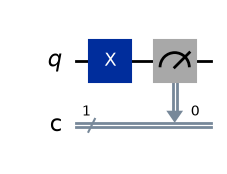

In [3]:
qc_a = QuantumCircuit(1, 1)
qc_a.x(0)
qc_a.measure(0, 0)

print('Circuit A:')
display(qc_a.draw('mpl'))

In [4]:
compiled_a = transpile(qc_a, simulator)
result_a = simulator.run(compiled_a, shots=SHOTS).result()
counts_a = result_a.get_counts()

print('Circuit A measurement counts:', counts_a)
plot_histogram(counts_a, title='Circuit A: One X Gate (100 shots)')
plt.show()

Circuit A measurement counts: {'1': 100}


## 4. Circuit B — Apply two X gates and measure

Circuit B:


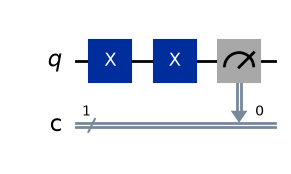

In [5]:
qc_b = QuantumCircuit(1, 1)
qc_b.x(0)
qc_b.x(0)
qc_b.measure(0, 0)

print('Circuit B:')
display(qc_b.draw('mpl'))

In [6]:
compiled_b = transpile(qc_b, simulator)
result_b = simulator.run(compiled_b, shots=SHOTS).result()
counts_b = result_b.get_counts()

print('Circuit B measurement counts:', counts_b)
plot_histogram(counts_b, title='Circuit B: Two X Gates (100 shots)')
plt.show()

Circuit B measurement counts: {'0': 100}


## 5. Circuit C — Apply one H gate and measure

Circuit C:


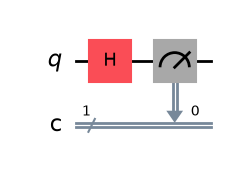

In [7]:
qc_c = QuantumCircuit(1, 1)
qc_c.h(0)
qc_c.measure(0, 0)

print('Circuit C:')
display(qc_c.draw('mpl'))

In [8]:
compiled_c = transpile(qc_c, simulator)
result_c = simulator.run(compiled_c, shots=SHOTS).result()
counts_c = result_c.get_counts()

print('Circuit C measurement counts:', counts_c)
plot_histogram(counts_c, title='Circuit C: One H Gate (100 shots)')
plt.show()

Circuit C measurement counts: {'1': 57, '0': 43}


## 6. Compare predictions with actual results
The next cell summarizes the observed counts. Circuit A should produce only `1`, Circuit B should produce only `0`, and Circuit C should produce a mixture of `0` and `1` with counts that are usually close to 50 each.

In [9]:
all_counts = {'Circuit A (one X)': counts_a,
              'Circuit B (two X gates)': counts_b,
              'Circuit C (one H)': counts_c}

for name, counts in all_counts.items():
    zeros = counts.get('0', 0)
    ones = counts.get('1', 0)
    print(f'{name}: 0 -> {zeros}, 1 -> {ones}, total -> {sum(counts.values())}')

Circuit A (one X): 0 -> 0, 1 -> 100, total -> 100
Circuit B (two X gates): 0 -> 100, 1 -> 0, total -> 100
Circuit C (one H): 0 -> 43, 1 -> 57, total -> 100


## 7. Conclusion

- **Circuit A:** The X gate flips the initial state `|0⟩` to `|1⟩`, so the expected measurement is `1`.
- **Circuit B:** Two X gates cancel each other, returning the qubit to `|0⟩`, so the expected measurement is `0`.
- **Circuit C:** The H gate creates an equal superposition. Measurement can return either `0` or `1`; across 100 shots, the counts are expected to be approximately balanced, but not necessarily exactly 50/50.

**Submission checklist:** Three circuits included; predictions written before execution; 100 shots per circuit; measurement counts recorded; histograms displayed; comparison and conclusion included.